In [ ]:
import os
import shutil
import pathlib
from typing import Sequence

#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization,Flatten
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error

In [ ]:
old_dir = pathlib.Path('../../data/dogs-vs-cats/train')

In [ ]:
old_dir

In [ ]:
new_dir = pathlib.Path('dogs-vs-cats_data')

In [ ]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir = new_dir/sub_n/i
        os.makedirs(dir)
        f_ns = [ f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n, dst=dir/f_n)

In [ ]:
make_subset('tr_data', 0, 1000)

In [ ]:
make_subset('tt_data', 1000, 2000)

In [ ]:
from keras.utils import image_dataset_from_directory
tr_ds=image_dataset_from_directory(new_dir/'tr_data',batch_size=32,image_size=(180,180))
tt_ds=image_dataset_from_directory(new_dir/'tt_data',batch_size=32,image_size=(180,180))

In [ ]:
tr_ds

In [ ]:
m = Sequential()
m.add(Input(shape=(180, 180, 3)))
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(tr_ds, epochs=5)

In [ ]:
#              scale: Any,
#              offset: float = 0.0,
#              **kwargs: Any

In [ ]:
# 데이터 변환 계층
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 데이터 증강 계층

In [ ]:
m = Sequential()
m.add(Input(shape=(180, 180, 3)))
m.add(Rescaling(scale=1./255)) # Rescaling(scale=1./127.5, offset = -1) -> -1~1 로 범주 정의
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(100, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

# m.summary()
m.compile(loss='binary_crossentropy', metrics=['acc'])
hy = m.fit(tr_ds, epochs=3)

In [ ]:
for imgs,ys in tr_ds.take(1):
    print(imgs.shape)
    plt.imshow(imgs[0].numpy().astype('uint8'))
    plt.show()
    break

In [ ]:
# 데이터 증강 확인
#(텐서, 라벨)
for imgs,ys in tr_ds:
    plt.imshow(imgs[0].numpy().astype('uint8'))
    plt.show()
    break

In [ ]:
# 데이터 변환 계층
from keras.layers import Rescaling, RandomZoom, RandomRotation, RandomFlip # 데이터 증강 계층

In [ ]:
# 데이터가 변환 되는 것은 아니다
data_add_m = Sequential()
data_add_m.add(RandomZoom(0.2))
data_add_m.add(RandomRotation(0.1))
for imgs, ys in tr_ds:
    data1 = data_add_m(imgs)
    print(data1.shape)
    for k in range(9):
        ax = plt.subplot(3, 3, k+1)
        plt.imshow(data1[k].numpy().astype('uint8'))
        plt.axis('off')
    plt.show()
    break

# **로드한 데이터 셋을 이용하여 최적의 모델을 설계후 학습된 모델을 완성하시오**
1. 우리가 형성한 데이터셋 함수를 이용하여 데이터를 늘리시오(최대 5000장)
2. 학습,테스트, 검증 데이터셋을 구성하여 사용하시오
3. 데이터 스케일링은 계층을 이용하시오
4. 데이터 증강 계층을 사용하시오
    - 1번 모델은 사용안함
    - 2번 모델은 사용함
    - 단 데이터는 변경 되면 안됨

In [3]:
# ===== 라이브러리 임포트 =====

# 시스템 및 파일 관리
import os
import shutil
import pathlib

# 데이터 분석 및 시각화
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 머신러닝 도구
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error

# Keras 모델 관련
from keras.models import Sequential, load_model

# Keras 레이어
from keras.layers import (
   Input, Dense, Conv2D, MaxPooling2D, Dropout, 
   SimpleRNN, LSTM, GRU, BatchNormalization, 
   Flatten, Activation, Rescaling
)

# 데이터 증강 레이어
from keras.layers import RandomFlip, RandomRotation, RandomZoom

# 최적화 알고리즘
from keras.optimizers import Adam, RMSprop, SGD, Adagrad

# 손실 함수
from keras.losses import (
   binary_crossentropy, categorical_crossentropy, 
   sparse_categorical_crossentropy, mean_squared_error
)

# 콜백 함수
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
old_dir = pathlib.Path('../../data/dogs-vs-cats/train')
new_dir = pathlib.Path('./dogs-vs-cats_data_test')

In [4]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir = new_dir/sub_n/i
        os.makedirs(dir)
        f_ns = [ f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n, dst=dir/f_n)

In [5]:
# 1번
new_dir = pathlib.Path('./dogs-vs-cats_data_test')
make_subset('tr_data', 0, 5000)
make_subset('tt_data', 5000, 10000)

In [5]:
# 2번
from keras.utils import image_dataset_from_directory
tr_ds = image_dataset_from_directory(
    new_dir/'tr_data',
    validation_split=0.2,
    subset="training",
    seed=100,
    image_size=(180, 180),
    batch_size=32
)
val_ds = image_dataset_from_directory(
    new_dir/'tr_data',
    validation_split=0.2,   # train과 동일한 split 값
    subset="validation",    # → "나머지 20%" 부분을 val_ds 로 가져옴
    seed=100,               # seed 동일해야 train/val 이 겹치지 않음
    image_size=(180, 180),
    batch_size=32
)

tt_ds=image_dataset_from_directory(
    new_dir/'tt_data',
    batch_size=32,
    image_size=(180,180)
)

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.
Found 10000 files belonging to 2 classes.


In [4]:
# tr_ds, val_ds, tt_ds 데이터셋 확인
print(f"Train dataset: {tr_ds}")
print(f"Validation dataset: {val_ds}")
print(f"Test dataset: {tt_ds}")

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [5]:
# 현재경로위치
print(os.getcwd())

/Users/ihanjo/Library/CloudStorage/GoogleDrive-ihann5726@gmail.com/내 드라이브/인공지능 사관학교/Coding/8월/8-20


In [14]:
m = Sequential([
    Input(shape=(180, 180, 3)),

    # 정규화 레이어 추가 (매우 중요!)
    Rescaling(1/255.0),
    
    # 첫 번째 블록
    Conv2D(32, (3,3), padding='same', activation='relu'),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    MaxPooling2D(2),
    
    # 두 번째 블록
    Conv2D(64, (3,3), padding='same', activation='relu'),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D(2),
    
    # 세 번째 블록
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D(2),
    
    # 세 번째 블록
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D(2),

    # 분류기
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
    
])

m.compile(
    optimizer=Adam(learning_rate=0.0002),  # 학습률 증가
    loss='binary_crossentropy', 
    metrics=['accuracy']  
)
m.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,777 (16.78 MB)

 Trainable params: 4,399,777 (16.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 콜백
es_fixed = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
ck_fixed = ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)

# 학습
hy = m.fit(
    tr_ds, 
    validation_data=val_ds, 
    epochs=100,  # 에포크 수 줄임
    callbacks=[es_fixed, ck_fixed],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5085 - loss: 0.6942
Epoch 1: val_loss improved from inf to 0.69194, saving model to best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.5085 - loss: 0.6942 - val_accuracy: 0.5015 - val_loss: 0.6919
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5569 - loss: 0.6760
Epoch 2: val_loss improved from 0.69194 to 0.59847, saving model to best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.5571 - loss: 0.6759 - val_accuracy: 0.6745 - val_loss: 0.5985
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6899 - loss: 0.5864
Epoch 3: val_loss improved from 0.59847 to 0.52792, saving model to best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.6899 - loss: 0.5864 - val_accuracy: 0.7335 - val_loss: 0.5279
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7276 - loss: 0.5372
Epoch 4: val_loss did not improve from 0

: 

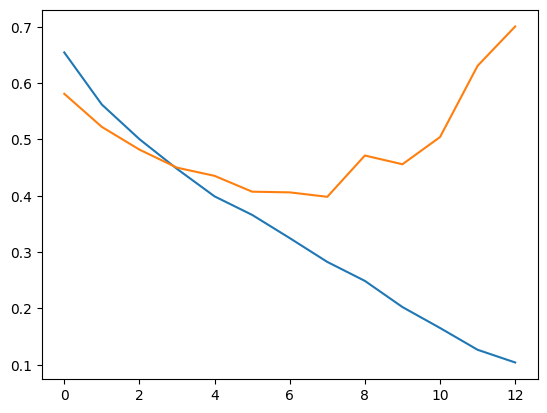

In [11]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])
plt.show()

In [ ]:
m1 = Sequential([
    Input(shape=(180, 180, 3)),

    # 정규화 레이어 추가 (매우 중요!)
    Rescaling(1./255),
    RandomRotation(0.1),
    RandomZoom(0.2),
    
    # 첫 번째 블록 (Conv -> BN -> Activation 순서)
    Conv2D(32, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(32, (3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.25),
    
    # 두 번째 블록
    Conv2D(64, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(64, (3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.3),
    
    # 세 번째 블록
    Conv2D(128, (3,3), padding='same'),
    Activation('relu'),
    Conv2D(128, (3,3), padding='same'),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.3),
    
    # 분류기
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

m1.compile(
    optimizer=Adam(learning_rate=0.0002),  # 학습률 증가
    loss='binary_crossentropy', 
    metrics=['accuracy']  
)
m1.summary()


In [6]:
# Keras 레이어
from keras.layers import (
   Input, Dense, Conv2D, MaxPooling2D, Dropout, 
   SimpleRNN, LSTM, GRU, BatchNormalization, GlobalAveragePooling2D,
   Flatten, Activation, Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomContrast
)

# 데이터 증강 레이어
from keras.layers import RandomFlip, RandomRotation, RandomZoom

# 최적화 알고리즘
from keras.optimizers import Adam, RMSprop, SGD, Adagrad

# 손실 함수
from keras.losses import (
   binary_crossentropy, categorical_crossentropy, 
   sparse_categorical_crossentropy, mean_squared_error
)

# 콜백 함수
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


In [7]:
m2 = Sequential([
    Input(shape=(180, 180, 3)),

    # 데이터 증강 (매개변수 명시적 표기)
    Rescaling(1./255),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomTranslation(height_factor=0.1, width_factor=0.1),
    RandomContrast(factor=0.2),

    # 첫 번째 블록
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.3),

    # 두 번째 블록
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.3),

    # 세 번째 블록
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.3),

    # 네 번째 블록
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.3),

    # 분류기 (개선된 버전)
    GlobalAveragePooling2D(),
    
    # 첫 번째 Dense 층
    Dense(256),  # 뉴런 수를 128에서 256으로 늘려봄
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5), # 높은 Dropout 비율 적용
    
    # 두 번째 Dense 층
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    # 최종 출력 층
    Dense(1, activation='sigmoid')
])

m2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

m2.summary()


# 콜백
es_fixed = EarlyStopping(patience=15, restore_best_weights=True, verbose=1)
ck_fixed = ModelCheckpoint('edit_m2.keras', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# 학습
hy1 = m2.fit(
    tr_ds, 
    validation_data=val_ds, 
    epochs=100,  # 에포크 수 줄임
    callbacks=[es_fixed, ck_fixed, reduce_lr],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 180, 180, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 180, 180, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,449 (4.87 MB)

 Trainable params: 1,273,761 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.5336 - loss: 0.8133
Epoch 1: val_loss improved from inf to 0.78438, saving model to edit_m2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 205ms/step - accuracy: 0.5336 - loss: 0.8131 - val_accuracy: 0.5010 - val_loss: 0.7844 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5555 - loss: 0.7304
Epoch 2: val_loss improved from 0.78438 to 0.65353, saving model to edit_m2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 202ms/step - accuracy: 0.5555 - loss: 0.7303 - val_accuracy: 0.5930 - val_loss: 0.6535 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.5956 - loss: 0.6841
Epoch 3: val_loss improved from 0.65353 to 0.62716, saving model to edit_m2.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.5956 - loss: 0.6841 - val_accuracy: 0.6385 - val_loss: 0.6272 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 195

In [8]:
# 콜백
es_fixed = EarlyStopping(patience=10, restore_best_weights=True, verbose=1)
ck_fixed = ModelCheckpoint('best_model1.keras', save_best_only=True, verbose=1)

# 학습
hy1 = m1.fit(
    tr_ds, 
    validation_data=val_ds, 
    epochs=100,  # 에포크 수 줄임
    callbacks=[es_fixed, ck_fixed],
)

NameError: name 'm1' is not defined

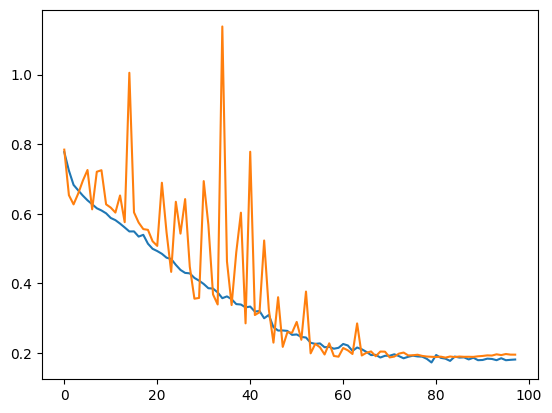

In [10]:
plt.plot(hy1.history['loss'])
plt.plot(hy1.history['val_loss'])
plt.show()

In [9]:
# 모델 평가
best_m = load_model('edit_m2.keras')


# 예측 및 결과 확인
tr_scs_m = best_m.evaluate(tr_ds)
val_scs_m = best_m.evaluate(val_ds)
tt_scs_m = best_m.evaluate(tt_ds)

all_acc_m=abs(tr_scs_m[1]-val_scs_m[1])+abs(tr_scs_m[1]-tt_scs_m[1])+abs(tt_scs_m[1]-val_scs_m[1])
print(f'all_acc_m : {all_acc_m}')

all_loss_m=abs(tr_scs_m[0]-val_scs_m[0])+abs(tr_scs_m[0]-tt_scs_m[0])+abs(tt_scs_m[0]-val_scs_m[0])
print(f'all_loss_m : {all_loss_m}')

250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9416 - loss: 0.1427
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9216 - loss: 0.2038
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9077 - loss: 0.2125
all_acc_m : 0.06290006637573242
all_loss_m : 0.13904955983161926


In [ ]:
# 모델 평가
best_m = load_model('best_model1.keras')

# 예측 및 결과 확인
tr_scs_m = best_m.evaluate(tr_ds)
val_scs_m = best_m.evaluate(val_ds)
tt_scs_m = best_m.evaluate(tt_ds)
print(tr_scs_m)
print(val_scs_m)
print(tt_scs_m)

all_acc_m=abs(tr_scs_m[1]-val_scs_m[1])+abs(tr_scs_m[1]-tt_scs_m[1])+abs(tt_scs_m[1]-val_scs_m[1])
print(f'all_acc_m : {all_acc_m}')

all_loss_m=abs(tr_scs_m[0]-val_scs_m[0])+abs(tr_scs_m[0]-tt_scs_m[0])+abs(tt_scs_m[0]-val_scs_m[0])
print(f'all_loss_m : {all_loss_m}')

In [ ]:
import shutil
import pathlib

# 삭제할 폴더 경로
target_dir = pathlib.Path('./dogs-vs-cats_data')

# 폴더가 존재하면 삭제
if target_dir.exists() and target_dir.is_dir():
    shutil.rmtree(target_dir)
    print(f"{target_dir} 삭제 완료")
else:
    print(f"{target_dir} 폴더 없음")


In [ ]:
# 현재 학습 중단 후 이 코드 실행
import tensorflow as tf
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam

print("=== 개고양이 데이터셋 디버깅 ===")

# 1. 데이터셋 확인
print("1. 데이터셋 정보:")
for data_batch, labels_batch in tr_ds.take(1):
    print(f"이미지 shape: {data_batch.shape}")
    print(f"라벨 shape: {labels_batch.shape}")
    print(f"이미지 값 범위: {tf.reduce_min(data_batch):.3f} ~ {tf.reduce_max(data_batch):.3f}")
    print(f"라벨 고유값: {tf.unique(labels_batch)[0].numpy()}")
    print(f"라벨 평균: {tf.reduce_mean(tf.cast(labels_batch, tf.float32)):.3f}")
    break

In [ ]:
import threading
import time
from datetime import datetime
from IPython.display import clear_output
import pynvml
import psutil

# NVML 초기화
pynvml.nvmlInit()
gpu_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def monitor_system(interval=5):
    while True:
        clear_output(wait=True)
        now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # GPU 정보
        mem_info = pynvml.nvmlDeviceGetMemoryInfo(gpu_handle)
        temp = pynvml.nvmlDeviceGetTemperature(gpu_handle, pynvml.NVML_TEMPERATURE_GPU)
        power = pynvml.nvmlDeviceGetPowerUsage(gpu_handle) / 1000
        gpu_name = pynvml.nvmlDeviceGetName(gpu_handle).decode()
        utilization = pynvml.nvmlDeviceGetUtilizationRates(gpu_handle)

        # CPU 정보
        cpu_percent = psutil.cpu_percent(interval=0.5)
        cpu_freq = psutil.cpu_freq()
        ram = psutil.virtual_memory()

        # 출력
        print(f"🕒 {now}")
        print(f"🖥️ GPU: {gpu_name}")
        print(f"📊 GPU 메모리 사용량: {mem_info.used / 1024**3:.2f} GB / {mem_info.total / 1024**3:.2f} GB")
        print(f"📈 GPU 사용률: {utilization.gpu}%")
        print(f"🌡️ GPU 온도: {temp} °C")
        print(f"⚡ GPU 전력 소비: {power:.2f} W")
        print(f"🧠 CPU 사용률: {cpu_percent:.1f}%")
        print(f"🔄 CPU 클럭: {cpu_freq.current:.0f} MHz")
        print(f"💾 RAM 사용량: {ram.used / 1024**3:.2f} GB / {ram.total / 1024**3:.2f} GB")

        time.sleep(interval)

# 백그라운드에서 모니터링 시작
threading.Thread(target=monitor_system, daemon=True).start()

In [ ]:
!pip install nvidia-ml-py3